In [1]:
import pandas as pd
filepath = 'https://raw.githubusercontent.com/selva86/datasets/master/Raotbl6.csv'
df_comp = pd.read_csv(filepath, parse_dates=['date'], index_col='date')
print(df_comp.shape)  # (123, 8)
df_comp.tail()

(123, 8)


,rgnp,pgnp,ulc,gdfco,gdf,gdfim,gdfcf,gdfce
date,,,,,,,,
1988-07-01,4042.7,3971.9,179.6,131.5,124.9,106.2,123.5,92.8
1988-10-01,4069.4,3995.8,181.3,133.3,126.2,107.3,124.9,92.9
1989-01-01,4106.8,4019.9,184.1,134.8,127.7,109.5,126.6,94.0
1989-04-01,4132.5,4044.1,186.1,134.8,129.3,111.1,129.0,100.6
1989-07-01,4162.9,4068.4,187.4,137.2,130.2,109.8,129.9,98.2


In [2]:
dat=df_comp['gdfim']
dat.head()

date
1959-01-01    26.9
1959-04-01    27.0
1959-07-01    27.1
1959-10-01    27.1
1960-01-01    27.2
Name: gdfim, dtype: float64

In [3]:
import statsmodels.tsa.stattools as sts
result = sts.adfuller(dat)
print('p-value: %f' % result[1])

p-value: 0.938674


La serie no es estacionaria ya que 0.938674 > 0.05.
Apliquemos una transformación a la serie.

In [4]:
dat_transformed=dat.diff().dropna()
dat_transformed.tail()

date
1988-07-01    0.1
1988-10-01    1.1
1989-01-01    2.2
1989-04-01    1.6
1989-07-01   -1.3
Name: gdfim, dtype: float64

In [5]:
result = sts.adfuller(dat_transformed)
print('p-value: %f' % result[1])

p-value: 0.000554


Hemos obtenida una serie estacionaria.

In [6]:
!pip install pmdarima
#from pmdarima.arima import auto_arima
import pmdarima as pm


In [8]:
model_auto = pm.auto_arima(dat_transformed,d=0) #d=0 para evitar una nueva transformación

c:\Users\grego\OneDrive\Documentos\cursos\curso-series-temporales\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\grego\OneDrive\Documentos\cursos\curso-series-temporales\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\grego\OneDrive\Documentos\cursos\curso-series-temporales\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\grego\OneDrive\Documentos\cursos\curso-series-temporales\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\grego\OneDrive\

In [9]:
model_auto

,order,"(1, ...)"
,seasonal_order,"(0, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,True
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,{}
,trend,None
,with_intercept,True


In [10]:
pred=model_auto.predict(n_periods = 10)
df_auto_pred = pd.DataFrame(pred)

c:\Users\grego\OneDrive\Documentos\cursos\curso-series-temporales\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [11]:
df_forecast= dat.iloc[-1] + df_auto_pred.cumsum()

<Axes: >

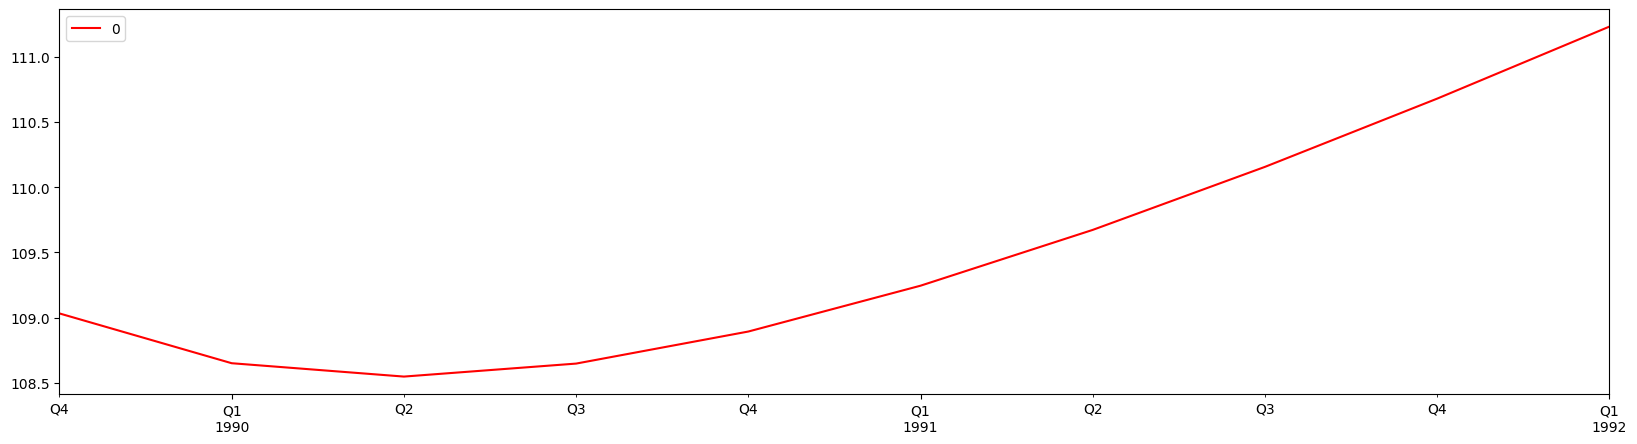

In [12]:
df_forecast.plot(figsize = (20,5), color = "red")

In [ ]:
dates=pd.date_range(start="1989-10-01",freq='QS',periods=10) # Crea una lista de fechas cuatrimestrales.
dates

DatetimeIndex(['1989-10-01', '1990-01-01', '1990-04-01', '1990-07-01',
               '1990-10-01', '1991-01-01', '1991-04-01', '1991-07-01',
               '1991-10-01', '1992-01-01'],
              dtype='datetime64[ns]', freq='QS-JAN')

In [15]:
df_forecast.index=dates
df_forecast.columns=['Predictions']
df_forecast.head()

,Predictions
1989-10-01,109.033172
1990-01-01,108.651989
1990-04-01,108.549744
1990-07-01,108.649255
1990-10-01,108.894696


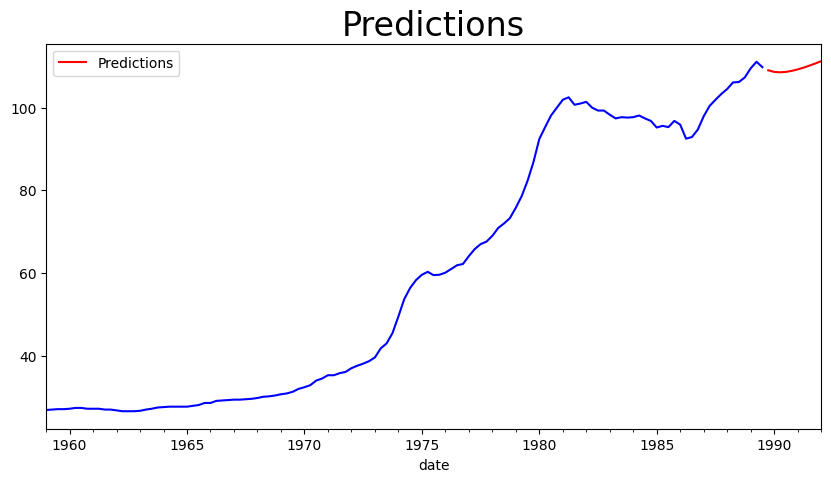

In [16]:
import matplotlib.pyplot as plt

df_forecast.plot(figsize = (10,5), color = "red")
dat.plot(color = "blue")
plt.title("Predictions", size = 24)
plt.show()